##Kudzu vine model

01 - Patch construction

02 - Grid Search

03 - PSO

04 - Simulation

**05 - Map**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import box
import os
import zipfile
import warnings

In [ ]:
## country boundaries
country_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/data/country_boundary/"

print(os.listdir(country_path))

['CNTR_RG_10M_2016_3035.gpkg']


In [ ]:
countries = gpd.read_file(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/data/country_boundary/CNTR_RG_10M_2016_3035.gpkg"
)

In [ ]:
## read study laryers

gpkg = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_plot_layers.gpkg")

patches = gpd.read_file(gpkg, layer="patches")
land = gpd.read_file(gpkg, layer="land")
water = gpd.read_file(gpkg, layer="water")
study_area = gpd.read_file(gpkg, layer="study_area")
inland_water = gpd.read_file(gpkg, layer="inland_water")

In [ ]:
import pyogrio

pyogrio.list_layers(gpkg)

array([['patches', 'Polygon'],
       ['land', 'Polygon'],
       ['water', 'Polygon'],
       ['study_area', 'Polygon'],
       ['inland_water', 'MultiPolygon Z']], dtype=object)

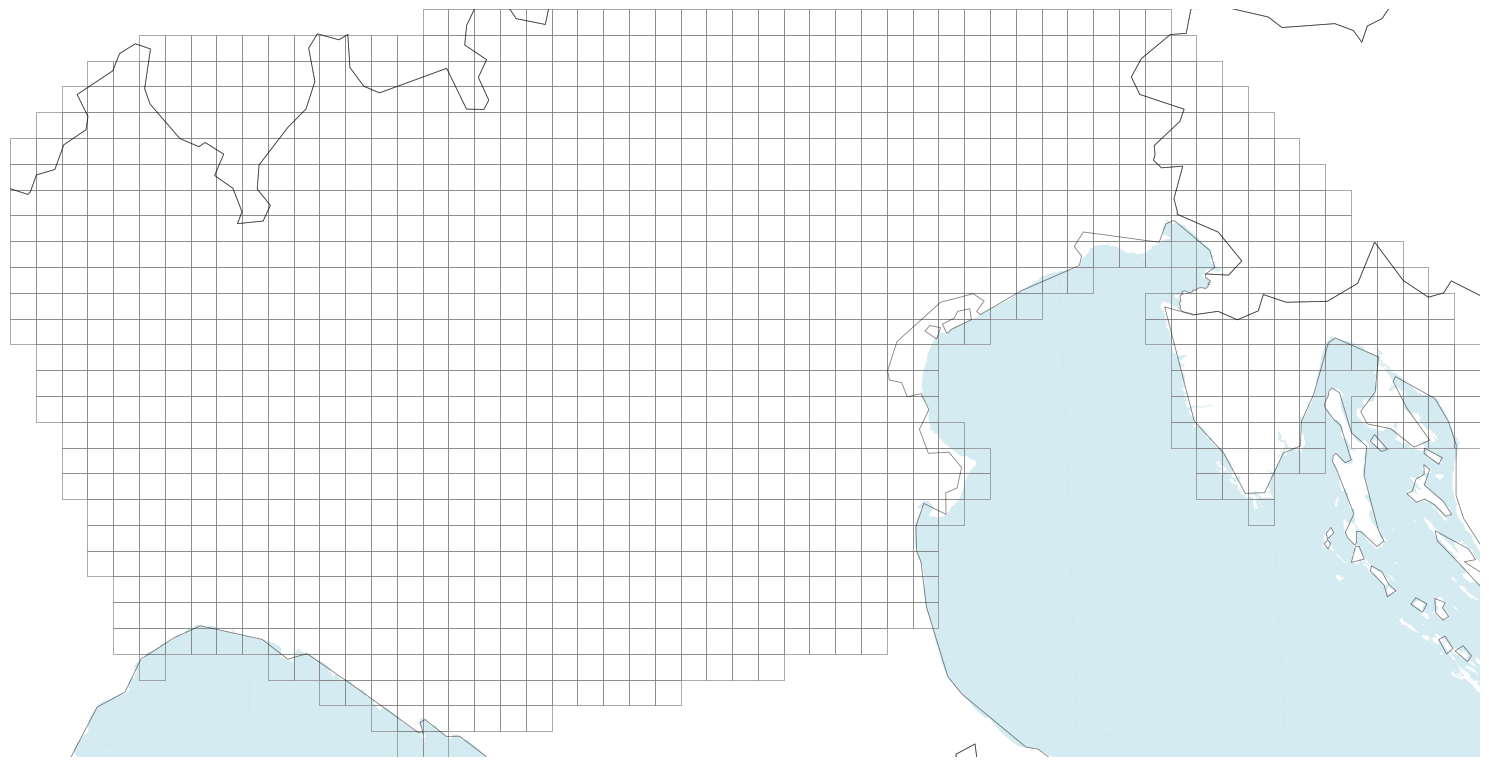

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))

water.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.5,
    zorder=1
)

land.plot(
    ax=ax,
    facecolor="white",
    edgecolor="none",
    alpha=0.5,
    zorder=2
)

patches.boundary.plot(
    ax=ax,
    color="grey",
    alpha=0.8,
    linewidth=0.6,
    zorder=3
)

countries.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.6,
    alpha=0.5,
    zorder=4
)

xmin, ymin, xmax, ymax = study_area.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
ax.set_axis_off()

plt.tight_layout()
plt.show()



---



In [ ]:
patches.head()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i,land_centroid,geometry
0,0,100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0,POINT (4153207.639024 2552998.956536),"POLYGON ((4158207.639 2547998.957, 4158207.639..."
1,1,100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2542998.956536),"POLYGON ((4158207.639 2537998.957, 4158207.639..."
2,2,100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2532998.956536),"POLYGON ((4158207.639 2527998.957, 4158207.639..."
3,3,100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0,POINT (4153207.639024 2522998.956536),"POLYGON ((4158207.639 2517998.957, 4158207.639..."
4,4,100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2512998.956536),"POLYGON ((4158207.639 2507998.957, 4158207.639..."


In [ ]:
patches = gpd.read_file(
    gpkg,
    layer="patches"
)

display(patches.drop(columns="geometry").head())

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i,land_centroid
0,0,100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0,POINT (4153207.639024 2552998.956536)
1,1,100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2542998.956536)
2,2,100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2532998.956536)
3,3,100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0,POINT (4153207.639024 2522998.956536)
4,4,100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0,POINT (4153207.639024 2512998.956536)


In [ ]:
summary_results_gs = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_summary_results_gs.csv"
)

patch_results_gs = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_patch_results_gs.csv"
)

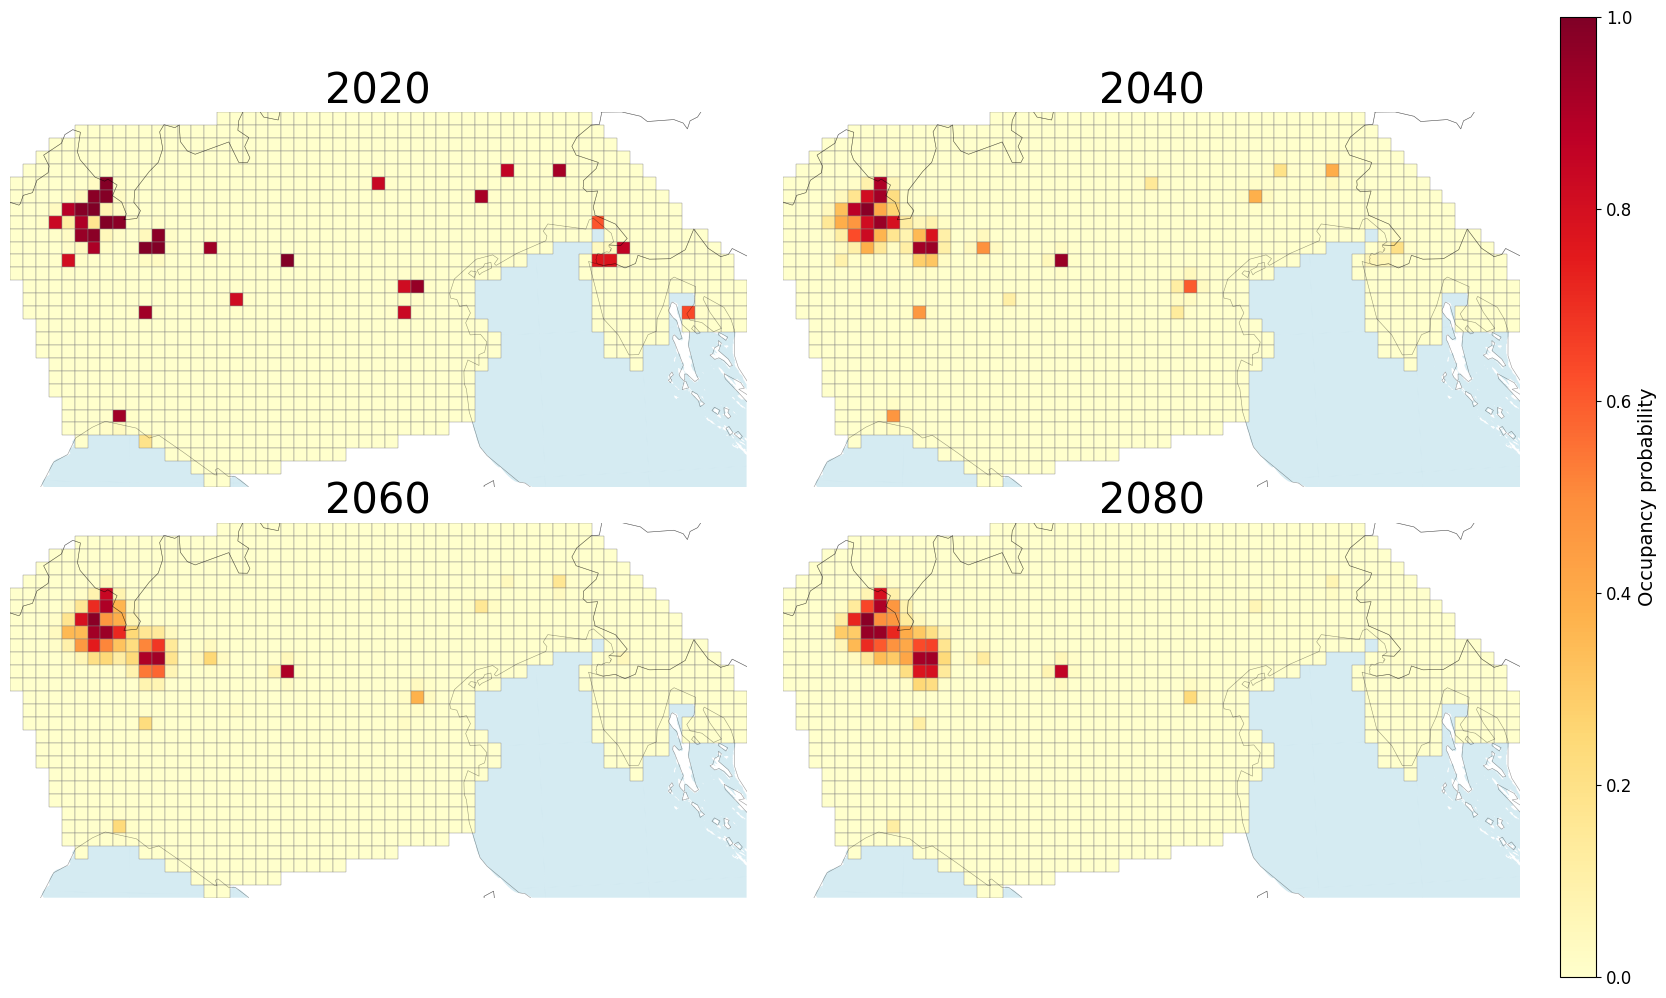

In [ ]:
map_kudzu_gs = patches.merge(
    patch_results_gs,
    on="patch_id",
    how="left"
)

years = [2020, 2040, 2060, 2080]

fig, axes = plt.subplots(
    2, 2,
    figsize=(20, 16)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_kudzu_gs[
        map_kudzu_gs["year"] == year
    ].copy()

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.4,
        alpha=0.4,
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        str(year),
        fontsize=30
    )

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

plt.subplots_adjust(
    right=0.88,
    hspace=-0.5,
    wspace=0.05
)

cax = fig.add_axes([
    0.90,
    0.20,
    0.018,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    "Occupancy probability",
    fontsize=14
)

cbar.ax.tick_params(
    labelsize=12
)

plt.show()

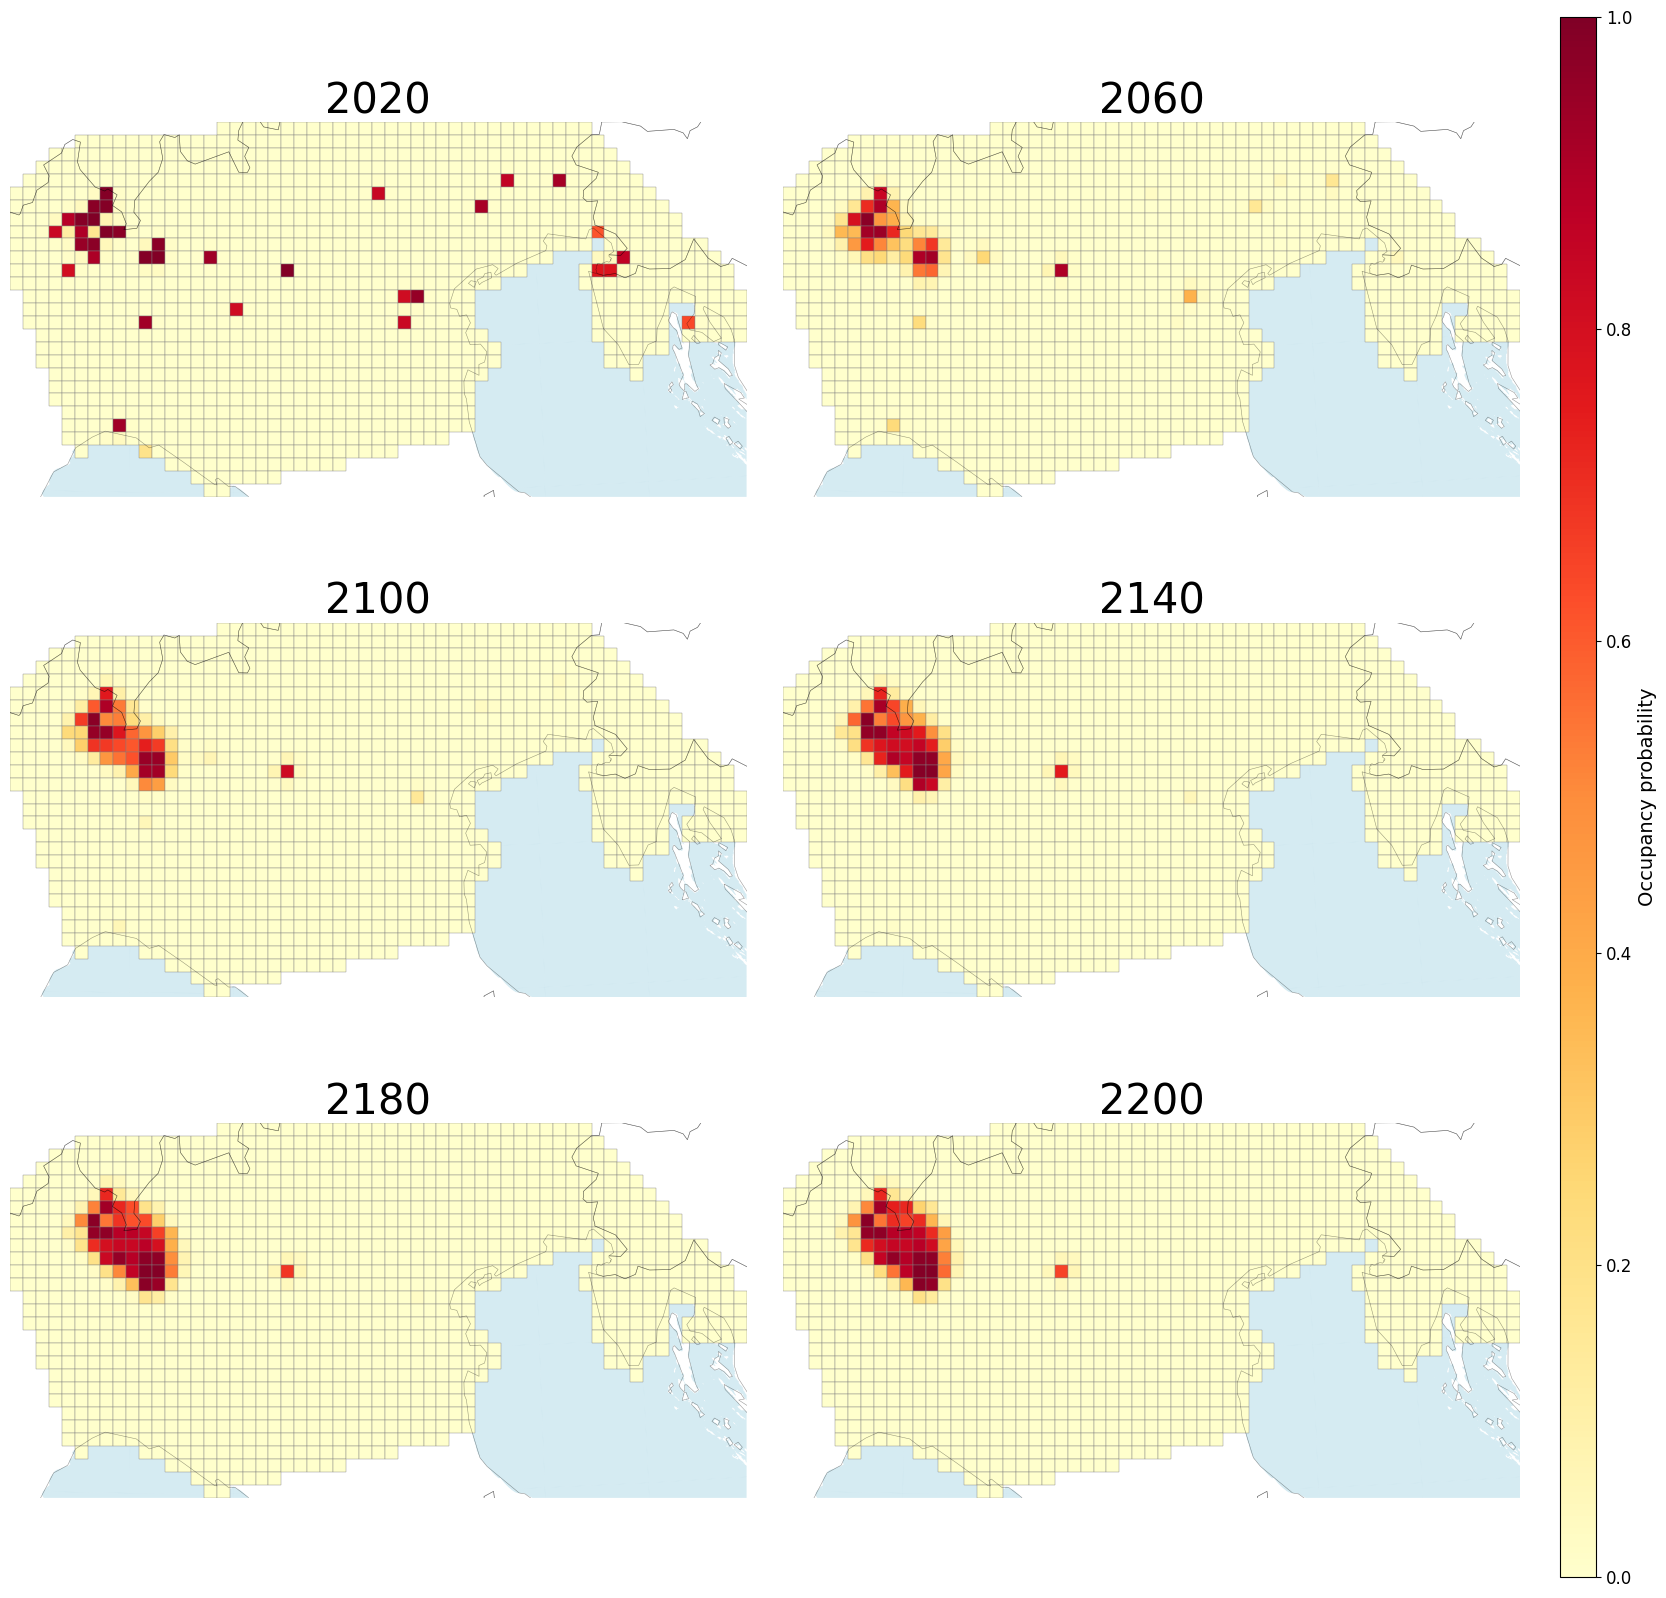

In [ ]:
map_kudzu_gs = patches.merge(
    patch_results_gs,
    on="patch_id",
    how="left"
)

years = [2020, 2060, 2100, 2140, 2180, 2200]

fig, axes = plt.subplots(
    3, 2,
    figsize=(20, 26)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_kudzu_gs[
        map_kudzu_gs["year"] == year
    ].copy()

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.4,
        alpha=0.4,
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        str(year),
        fontsize=30
    )

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

plt.subplots_adjust(
    right=0.88,
    hspace=-0.5,
    wspace=0.05
)

cax = fig.add_axes([
    0.90,
    0.20,
    0.018,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    "Occupancy probability",
    fontsize=14
)

cbar.ax.tick_params(
    labelsize=12
)

plt.show()

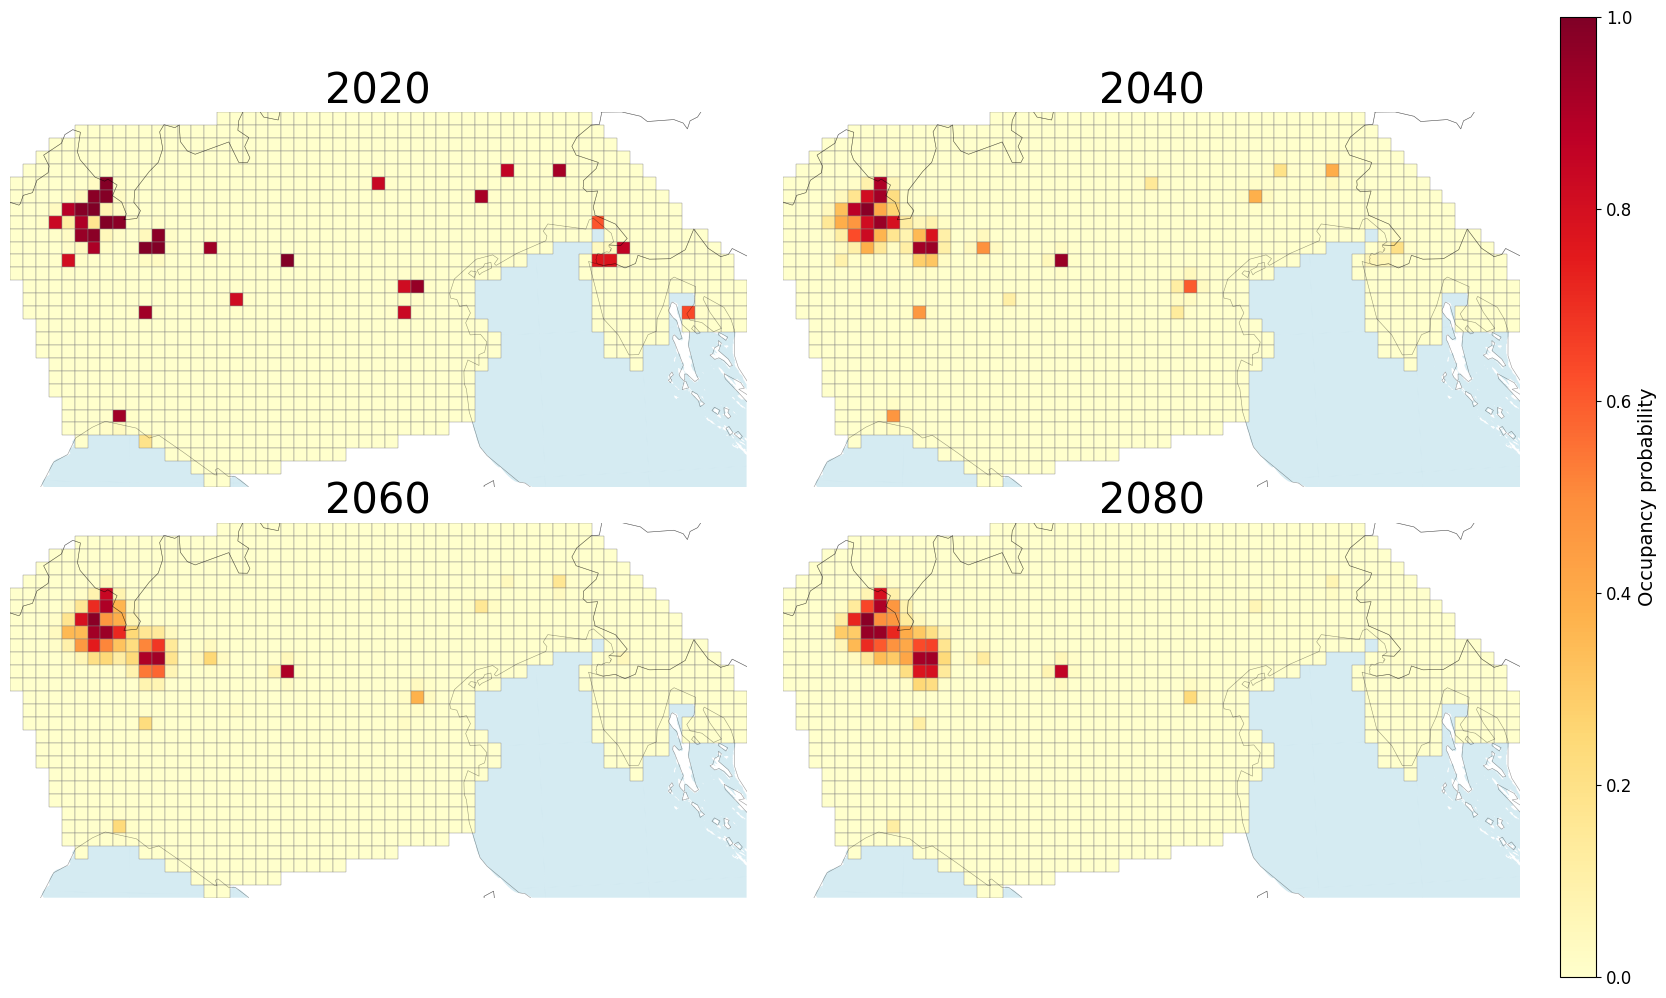

In [ ]:
map_kudzu_gs = patches.merge(
    patch_results_gs,
    on="patch_id",
    how="left"
)

years = [2020, 2040, 2060, 2080]

fig, axes = plt.subplots(
    2, 2,
    figsize=(20, 16)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_kudzu_gs[
        map_kudzu_gs["year"] == year
    ].copy()

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.4,
        alpha=0.4,
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        str(year),
        fontsize=30
    )

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

plt.subplots_adjust(
    right=0.88,
    hspace=-0.5,
    wspace=0.05
)

cax = fig.add_axes([
    0.90,
    0.20,
    0.018,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    "Occupancy probability",
    fontsize=14
)

cbar.ax.tick_params(
    labelsize=12
)

plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

years = [ year for year in sorted(map_kudzu_gs["year"].unique())
    if 2020 <= year <= 2220 and (year - 2020) % 10 == 0]

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Occupancy probability",
    fontsize=13
)

cbar.ax.tick_params(labelsize=11)

def update(year):

    ax.clear()

    map_year = map_kudzu_gs[
        map_kudzu_gs["year"] == year
    ]

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )

    countries.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.4,
    alpha=0.5,
    zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        f"{int(year)}",
        fontsize=22
    )

animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=800,
    repeat=True
)

display(HTML(animation.to_jshtml()))

gif_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_GS_projection.gif")

animation.save(
    gif_path,
    writer=PillowWriter(fps=1.25),
    dpi=120
)

plt.close(fig)

In [ ]:
summary_results_pso = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_summary_results_pso.csv"
)

patch_results_pso = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_patch_results_pso.csv"
)

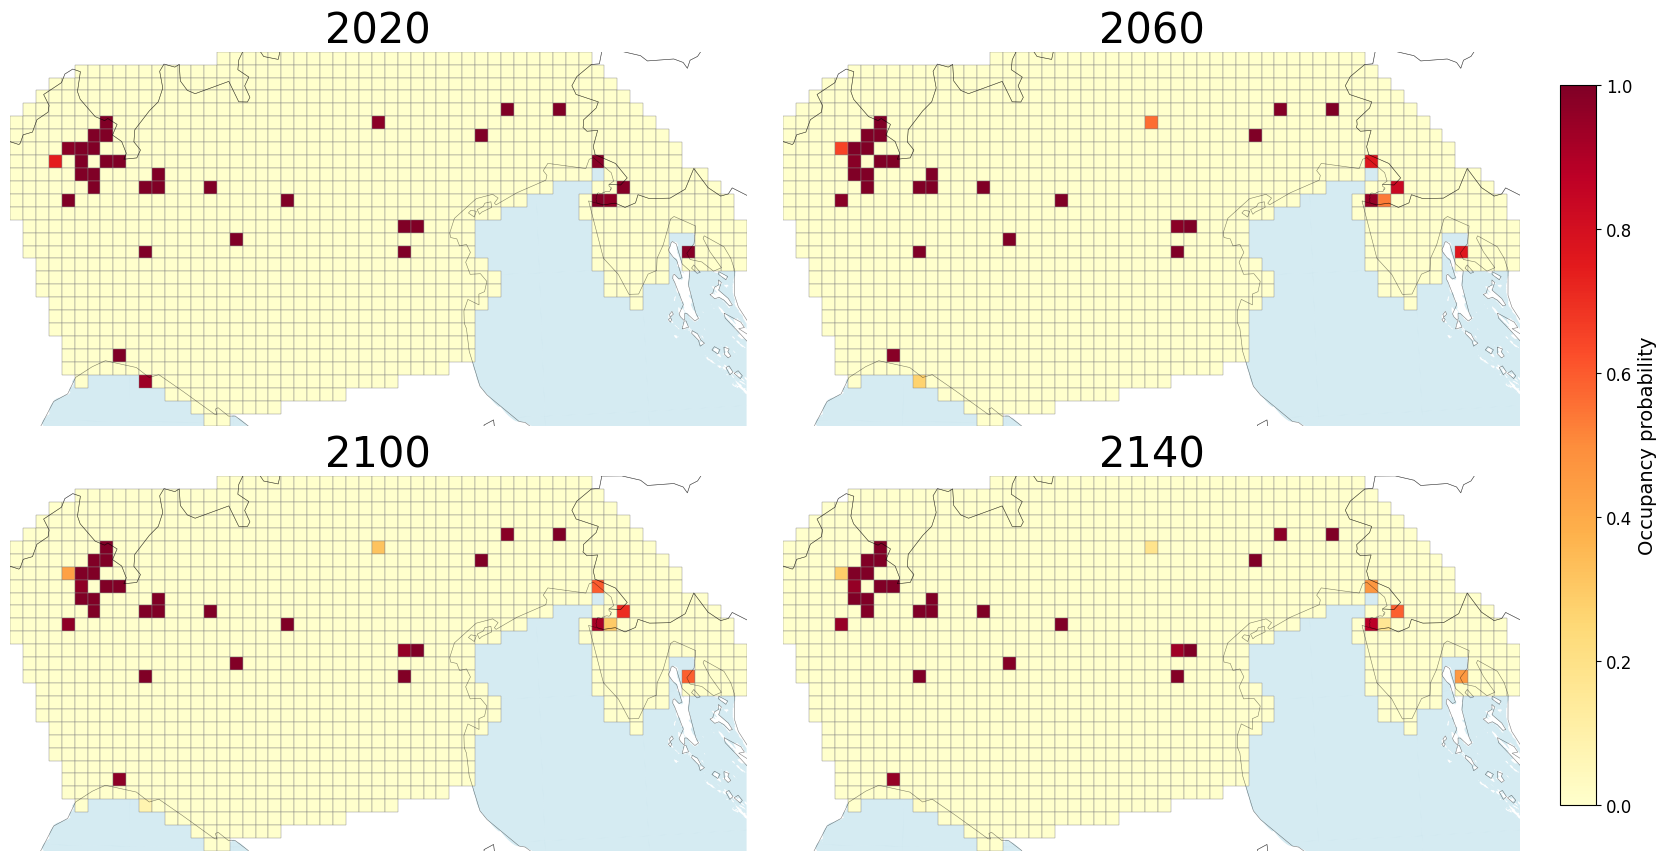

In [ ]:
map_kudzu_pso = patches.merge(
    patch_results_pso,
    on="patch_id",
    how="left"
)

years = [2020, 2060, 2100, 2140]

fig, axes = plt.subplots(
    2, 2,
    figsize=(20, 12)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_kudzu_pso[
        map_kudzu_pso["year"] == year
    ].copy()

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.4,
        alpha=0.5,
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        str(year),
        fontsize=30
    )

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

plt.subplots_adjust(
    right=0.88,
    hspace=-0.15,
    wspace=0.05
)

cax = fig.add_axes([
    0.90,
    0.20,
    0.018,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    "Occupancy probability",
    fontsize=14
)

cbar.ax.tick_params(
    labelsize=12
)

plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

years = [
    year for year in sorted(map_kudzu_pso["year"].unique())
    if 2020 <= year <= 2600 and (year - 2020) % 10 == 0
]

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Occupancy probability",
    fontsize=13
)

cbar.ax.tick_params(labelsize=11)

def update(year):

    ax.clear()

    map_year = map_kudzu_pso[
        map_kudzu_pso["year"] == year
    ]

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )
    countries.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.4,
    alpha=0.5,
    zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        f"{int(year)}",
        fontsize=22
    )

animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=200,   ## time interval
    repeat=True
)

display(HTML(animation.to_jshtml()))

gif_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "kudzu_PSO_projection_2300.gif")

animation.save(
    gif_path,
    writer=PillowWriter(fps=1.25),
    dpi=120
)

plt.close(fig)

Output hidden; open in https://colab.research.google.com to view.